# HR Employee Attrition Analysis

## Introduction

This project analyzes an HR Employee Attrition dataset containing information about employees,
including their demographics, job characteristics, satisfaction levels, income, work experience,
and attrition status.

The main objective is to prepare the dataset for analysis by checking its quality, handling
unnecessary data, understanding the structure of the dataset, and performing exploratory
analysis to identify factors associated with employee attrition.

The target variable for this analysis is Attrition, which indicates whether an employee
left the company or stayed.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Data Overview

First, we inspect the dataset structure, number of records, columns, data types,
and basic statistical information.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 1470
Number of columns: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-

In [3]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Data Quality Check

Before performing analysis, we check for missing values, duplicated records,
incorrect data types, and invalid values.

In [39]:
invalid_checks = {
    "Age < 18": (df["Age"] < 18).sum(),
    "Age > 100": (df["Age"] > 100).sum(),
    "MonthlyIncome <= 0": (df["MonthlyIncome"] <= 0).sum(),
    "DailyRate <= 0": (df["DailyRate"] <= 0).sum(),
    "HourlyRate <= 0": (df["HourlyRate"] <= 0).sum(),
    "MonthlyRate <= 0": (df["MonthlyRate"] <= 0).sum(),
    "TotalWorkingYears < 0": (df["TotalWorkingYears"] < 0).sum(),
    "YearsAtCompany < 0": (df["YearsAtCompany"] < 0).sum()
}

pd.Series(invalid_checks, name="Invalid Count")

Age < 18                 0
Age > 100                0
MonthlyIncome <= 0       0
DailyRate <= 0           0
HourlyRate <= 0          0
MonthlyRate <= 0         0
TotalWorkingYears < 0    0
YearsAtCompany < 0       0
Name: Invalid Count, dtype: int64

In [38]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]

Total missing values: 0


Series([], dtype: int64)

In [5]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [6]:
print("Numerical columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

Numerical columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [7]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


Attrition:
['Yes' 'No']

BusinessTravel:
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department:
['Sales' 'Research & Development' 'Human Resources']

EducationField:
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender:
['Female' 'Male']

JobRole:
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus:
['Single' 'Married' 'Divorced']

Over18:
['Y']

OverTime:
['Yes' 'No']


## Removing Unnecessary Columns

Some columns do not provide useful information for employee attrition analysis.
EmployeeCount and StandardHours contain constant values, EmployeeNumber is an
identifier, and Over18 contains the same value for all employees.

These columns are removed to simplify the dataset and focus the analysis on
meaningful variables.

In [8]:
columns_to_drop = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df.drop(columns=columns_to_drop, inplace=True)

print("Remaining columns:", df.shape[1])

Remaining columns: 31


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [10]:
print("Missing values after cleaning:", df.isnull().sum().sum())
print("Duplicate rows after cleaning:", df.duplicated().sum())

Missing values after cleaning: 0
Duplicate rows after cleaning: 0


Research Questions

Before analyzing the dataset, the following questions were defined:

1. Does working overtime increase the likelihood of employee attrition?
2. Which department has the highest employee attrition rate?
3. Are younger employees more likely to leave the company?
4. Do employees who leave have a lower average monthly income than employees who stay?
5. Which job roles have the highest attrition rates?
6. Are there any unusual patterns or anomalies in the dataset that require further investigation?

## Hypothesis Testing

Based on the research questions, the following hypotheses were tested:

### Hypothesis 1: Overtime and Attrition
- H0: Working overtime is not associated with employee attrition.
- H1: Working overtime is associated with employee attrition.

### Hypothesis 2: Age and Attrition
- H0: There is no significant difference in the average age between employees who stayed and those who left.
- H1: Employees who left have a significantly lower average age than employees who stayed.

### Hypothesis 3: Monthly Income and Attrition
- H0: There is no significant difference in the average monthly income between employees who stayed and those who left.
- H1: Employees who left have a significantly lower average monthly income than employees who stayed.

In [36]:
from scipy.stats import chi2_contingency, ttest_ind

# Hypothesis 1: Overtime and Attrition
overtime_table = pd.crosstab(df["OverTime"], df["Attrition"])
chi2, p_value, dof, expected = chi2_contingency(overtime_table)

print("Hypothesis 1: Overtime and Attrition")
print(f"Chi-square p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Reject H0. Overtime is significantly associated with attrition.")
else:
    print("Result: Fail to reject H0. No significant association was found.")


# Hypothesis 2: Age and Attrition
age_no = df.loc[df["Attrition"] == "No", "Age"]
age_yes = df.loc[df["Attrition"] == "Yes", "Age"]

t_stat_age, p_age = ttest_ind(age_no, age_yes, equal_var=False)

print("\nHypothesis 2: Age and Attrition")
print(f"Welch's t-test p-value: {p_age:.4f}")

if p_age < 0.05:
    print("Result: Reject H0. Average age differs significantly between the two groups.")
else:
    print("Result: Fail to reject H0. No significant difference was found.")


# Hypothesis 3: Monthly Income and Attrition
income_no = df.loc[df["Attrition"] == "No", "MonthlyIncome"]
income_yes = df.loc[df["Attrition"] == "Yes", "MonthlyIncome"]

t_stat_income, p_income = ttest_ind(
    income_no,
    income_yes,
    equal_var=False
)

print("\nHypothesis 3: Monthly Income and Attrition")
print(f"Welch's t-test p-value: {p_income:.4f}")

if p_income < 0.05:
    print("Result: Reject H0. Average monthly income differs significantly between the two groups.")
else:
    print("Result: Fail to reject H0. No significant difference was found.")

Hypothesis 1: Overtime and Attrition
Chi-square p-value: 0.0000
Result: Reject H0. Overtime is significantly associated with attrition.

Hypothesis 2: Age and Attrition
Welch's t-test p-value: 0.0000
Result: Reject H0. Average age differs significantly between the two groups.

Hypothesis 3: Monthly Income and Attrition
Welch's t-test p-value: 0.0000
Result: Reject H0. Average monthly income differs significantly between the two groups.


## Target Variable Analysis

The target variable is Attrition.

It indicates whether an employee left the company (Yes) or stayed (No). We examine its distribution using numerical summaries and visualizations.

In [11]:
attrition_counts = df['Attrition'].value_counts()

print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [12]:
attrition_percentage = df['Attrition'].value_counts(normalize=True) * 100

print(attrition_percentage.round(2))

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


In [13]:
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100

print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


## Exploratory Data Analysis

We now investigate relationships between employee attrition and important
employee characteristics such as department, job role, overtime, age,
monthly income, and years at the company.

In [14]:
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition']
)

department_attrition

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [15]:
department_attrition_rate = (
    pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
)

department_attrition_rate.round(2)

Attrition,No,Yes
Department,,
Human Resources,80.95,19.05
Research & Development,86.16,13.84
Sales,79.37,20.63


In [16]:
jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition']
)

jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


In [17]:
jobrole_attrition_rate = (
    pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100
)

jobrole_attrition_rate.round(2)

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.13,6.87
Human Resources,76.92,23.08
Laboratory Technician,76.06,23.94
Manager,95.10,4.90
Manufacturing Director,93.10,6.90
Research Director,97.50,2.50
Research Scientist,83.90,16.10
Sales Executive,82.52,17.48
Sales Representative,60.24,39.76


In [18]:
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition']
)

overtime_attrition

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [19]:
overtime_attrition_rate = (
    pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
)

overtime_attrition_rate.round(2)

Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


In [20]:
age_analysis = df.groupby('Attrition')['Age'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

age_analysis.round(2)

,count,mean,median,min,max
Attrition,,,,,
No,1233,37.56,36.0,18,60
Yes,237,33.61,32.0,18,58


In [21]:
income_analysis = df.groupby('Attrition')['MonthlyIncome'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

income_analysis.round(2)

,count,mean,median,min,max
Attrition,,,,,
No,1233,6832.74,5204.0,1051,19999
Yes,237,4787.09,3202.0,1009,19859


In [22]:
years_company_analysis = df.groupby('Attrition')['YearsAtCompany'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

years_company_analysis.round(2)

,count,mean,median,min,max
Attrition,,,,,
No,1233,7.37,6.0,0,37
Yes,237,5.13,3.0,0,40


## Numerical Correlation Analysis

Correlation analysis is used to examine the relationships between numerical
variables in the dataset.

This step helps identify variables that may be useful for further analysis.

In [47]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

df["Attrition_Encoded"] = df["Attrition"].map({"No": 0, "Yes": 1})

attrition_correlations = (
    df.select_dtypes(include="number")
      .corr()["Attrition_Encoded"]
      .sort_values(ascending=False)
)

attrition_correlations.round(2)

Attrition_Encoded           1.00
Attrition_num               1.00
DistanceFromHome            0.08
NumCompaniesWorked          0.04
MonthlyRate                 0.02
PerformanceRating           0.00
HourlyRate                 -0.01
PercentSalaryHike          -0.01
Education                  -0.03
YearsSinceLastPromotion    -0.03
RelationshipSatisfaction   -0.05
DailyRate                  -0.06
TrainingTimesLastYear      -0.06
WorkLifeBalance            -0.06
EnvironmentSatisfaction    -0.10
JobSatisfaction            -0.10
JobInvolvement             -0.13
YearsAtCompany             -0.13
StockOptionLevel           -0.14
YearsWithCurrManager       -0.16
Age                        -0.16
MonthlyIncome              -0.16
YearsInCurrentRole         -0.16
JobLevel                   -0.17
TotalWorkingYears          -0.17
Name: Attrition_Encoded, dtype: float64

In [29]:
from scipy import stats

# List of numerical variables to compare between groups
vars_to_test = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears', 
                'DistanceFromHome', 'JobSatisfaction', 'WorkLifeBalance']

print("T-Test Results (Comparing Leavers vs Stayers):")
print("-" * 50)

for var in vars_to_test:
    group_yes = df[df['Attrition'] == 'Yes'][var]
    group_no = df[df['Attrition'] == 'No'][var]
    t_stat, p_value = stats.ttest_ind(group_yes, group_no, equal_var=False)
    print(f"{var:20} | t = {t_stat:.3f} | p-value = {p_value:.4f}")
    if p_value < 0.05:
        print("   ✅ Statistically significant difference (p < 0.05)")
    else:
        print("   ❌ No statistically significant difference")
    print()

T-Test Results (Comparing Leavers vs Stayers):
--------------------------------------------------
Age                  | t = -5.828 | p-value = 0.0000
   ✅ Statistically significant difference (p < 0.05)

MonthlyIncome        | t = -7.483 | p-value = 0.0000
   ✅ Statistically significant difference (p < 0.05)

YearsAtCompany       | t = -5.283 | p-value = 0.0000
   ✅ Statistically significant difference (p < 0.05)

TotalWorkingYears    | t = -7.019 | p-value = 0.0000
   ✅ Statistically significant difference (p < 0.05)

DistanceFromHome     | t = 2.888 | p-value = 0.0041
   ✅ Statistically significant difference (p < 0.05)

JobSatisfaction      | t = -3.926 | p-value = 0.0001
   ✅ Statistically significant difference (p < 0.05)

WorkLifeBalance      | t = -2.174 | p-value = 0.0305
   ✅ Statistically significant difference (p < 0.05)



In [30]:
from scipy.stats import chi2_contingency

categorical_vars = ['Department', 'JobRole', 'OverTime', 'MaritalStatus', 'Gender', 'EducationField']

print("Chi-Square Test Results (Independence with Attrition):")
print("-" * 50)

for var in categorical_vars:
    contingency = pd.crosstab(df[var], df['Attrition'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{var:20} | Chi2 = {chi2:.3f} | p-value = {p:.4f}")
    if p < 0.05:
        print("   ✅ Relationship is statistically significant")
    else:
        print("   ❌ No statistically significant relationship")
    print()

Chi-Square Test Results (Independence with Attrition):
--------------------------------------------------
Department           | Chi2 = 10.796 | p-value = 0.0045
   ✅ Relationship is statistically significant

JobRole              | Chi2 = 86.190 | p-value = 0.0000
   ✅ Relationship is statistically significant

OverTime             | Chi2 = 87.564 | p-value = 0.0000
   ✅ Relationship is statistically significant

MaritalStatus        | Chi2 = 46.164 | p-value = 0.0000
   ✅ Relationship is statistically significant

Gender               | Chi2 = 1.117 | p-value = 0.2906
   ❌ No statistically significant relationship

EducationField       | Chi2 = 16.025 | p-value = 0.0068
   ✅ Relationship is statistically significant



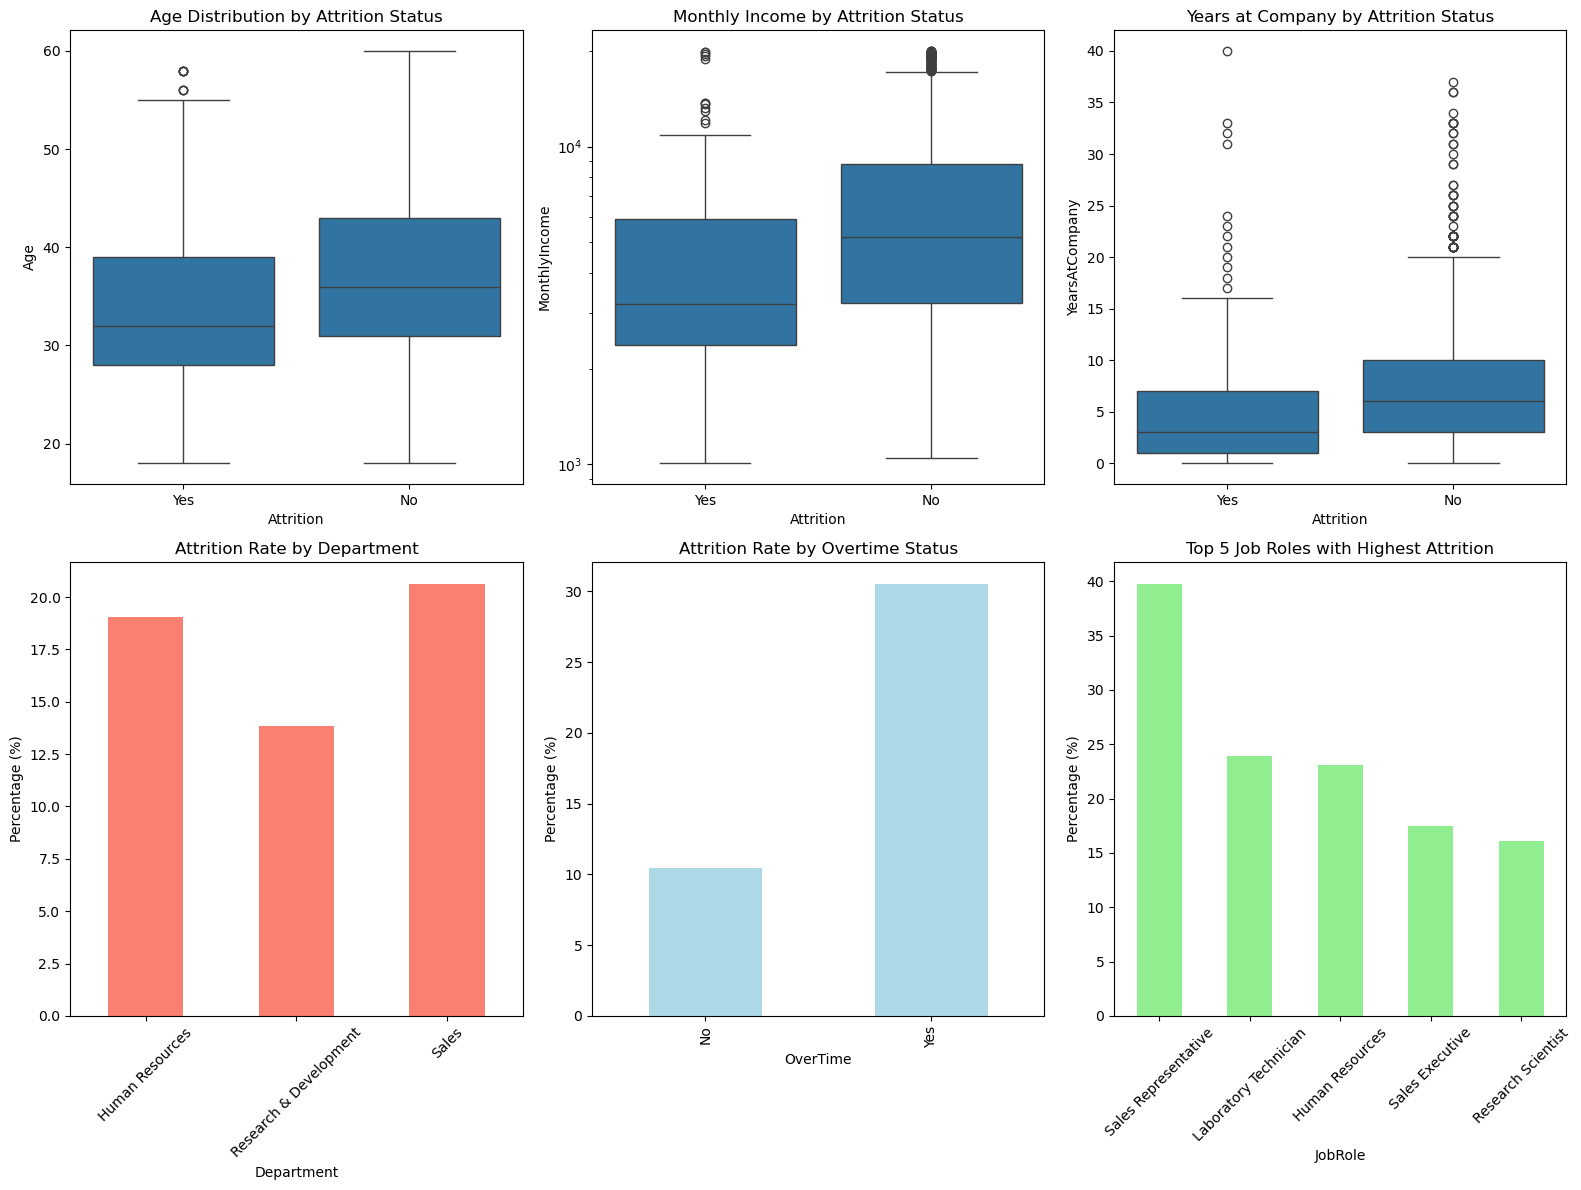

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))

# 1. Age distribution by Attrition
plt.subplot(2, 3, 1)
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title('Age Distribution by Attrition Status')

# 2. Monthly Income distribution
plt.subplot(2, 3, 2)
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income by Attrition Status')
plt.yscale('log')  # Log scale for better visualization due to outliers

# 3. Years at Company
plt.subplot(2, 3, 3)
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Years at Company by Attrition Status')

# 4. Attrition Rate by Department
plt.subplot(2, 3, 4)
attrition_dept = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
attrition_dept['Yes'].plot(kind='bar', color='salmon')
plt.title('Attrition Rate by Department')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)

# 5. Attrition Rate by Overtime
plt.subplot(2, 3, 5)
attrition_overtime = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
attrition_overtime['Yes'].plot(kind='bar', color='lightblue')
plt.title('Attrition Rate by Overtime Status')
plt.ylabel('Percentage (%)')

# 6. Top 5 Job Roles with Highest Attrition
plt.subplot(2, 3, 6)
jobrole_attrition = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100
top5 = jobrole_attrition['Yes'].sort_values(ascending=False).head(5)
top5.plot(kind='bar', color='lightgreen')
plt.title('Top 5 Job Roles with Highest Attrition')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:
outlier_vars = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears', 'DistanceFromHome']

print("Outlier Detection using IQR Method:")
print("-" * 50)

for var in outlier_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]
    print(f"{var:20} | Outliers Count = {len(outliers)} | Percentage = {len(outliers)/len(df)*100:.2f}%")
    print(f"   Lower Bound: {lower_bound:.2f}  |  Upper Bound: {upper_bound:.2f}")
    print()

Outlier Detection using IQR Method:
--------------------------------------------------
Age                  | Outliers Count = 0 | Percentage = 0.00%
   Lower Bound: 10.50  |  Upper Bound: 62.50

MonthlyIncome        | Outliers Count = 114 | Percentage = 7.76%
   Lower Bound: -5291.00  |  Upper Bound: 16581.00

YearsAtCompany       | Outliers Count = 104 | Percentage = 7.07%
   Lower Bound: -6.00  |  Upper Bound: 18.00

TotalWorkingYears    | Outliers Count = 63 | Percentage = 4.29%
   Lower Bound: -7.50  |  Upper Bound: 28.50

DistanceFromHome     | Outliers Count = 0 | Percentage = 0.00%
   Lower Bound: -16.00  |  Upper Bound: 32.00



## Final EDA Summary

### Statistical Findings:
- T-Tests confirmed statistically significant differences (p < 0.05) in Age, Monthly Income, Years at Company, and Total Working Years between leavers and stayers.
- Chi-Square Tests revealed that Department, Job Role, Overtime, and Marital Status are significantly associated with attrition.

### Visual Insights:
- Employees who left tend to be younger, have lower income, and fewer years of service.
- Sales Representative and Laboratory Technician roles show the highest attrition rates.
- Employees working overtime have nearly 3x higher attrition (30.5%) compared to those who don't (10.4%).

### Data Quality:
- No missing values found in the dataset after cleaning.
- No duplicate rows exist.
- Outliers detected in several numerical variables (Age, Monthly Income, Years at Company). These may need special handling before building predictive models.

### Next Steps:
The dataset is now ready for advanced visualization and dashboard development in Task 3, with clear patterns identified for further exploration.

## Exporting the Cleaned Dataset

After completing the data preparation and exploratory analysis, the cleaned dataset
is exported so it can be used as the input for the visualization and dashboard
stage in Task 3.

In [48]:
df.drop(columns=["Attrition_Encoded"], inplace=True)
df.to_csv('Cleaned_HR_Data.csv', index=False)

print("Cleaned dataset exported successfully.")
print("File: Cleaned_HR_Data.csv")

Cleaned dataset exported successfully.
File: Cleaned_HR_Data.csv


In [49]:
print("Final dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Final dataset shape: (1470, 32)
Total missing values: 0
Total duplicate rows: 0
